## Why KV Caching Makes LLMs Fast: A Hands-on Benchmark with GPT-2 Medium ⛳

## 1. Motivation:



---

Large Language Models generate text one token at a time.

At each step, the model attends to all previously generated tokens.

This raises an important question:

Do we really need to recompute everything at every step?

This notebook explores:
- Naive generation (no KV cache)
- Optimized generation (with KV cache)

We benchmark both approaches using GPT-2 Medium and analyze:
- Latency
- Scaling behavior
- Efficiency gains

## 2. Concept Explanation



---



## What is KV Caching?

In transformer models:
- Each token produces Key (K) and Value (V) vectors
- These are used in attention computation

Without caching:
- K and V are recomputed for the full sequence every step → O(n²)

With caching:
- Past K and V are stored and reused → O(n)

This optimization is critical for real-world LLM systems.

## 3.Setup



---



In [2]:
import torch
import time
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
model = AutoModelForCausalLM.from_pretrained("gpt2-medium").to(device)
tokenizer = AutoTokenizer.from_pretrained("gpt2-medium")

# Set to inference mode
""" We set the model to eval mode to:
      - Disable dropout
      - Ensure consistent benchmarking

    Without this, results may vary across runs."""

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

## 4.Baseline: No KV Cache



---



In [3]:
def generate_no_cache(prompt, max_new_tokens=100):
    """
    Naive generation:
    - At every step, the full sequence is passed to the model
    - This causes repeated recomputation of attention
    - This leads to quadratic complexity:O(1 + 2 + 3 + ... + n) ≈ O(n²)
    """

    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

    with torch.no_grad():
        for step in range(max_new_tokens):

            # Full recomputation for entire sequence
            outputs = model(input_ids)

            # Select next token (greedy decoding)
            next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)

            # Append token to sequence
            input_ids = torch.cat([input_ids, next_token], dim=1)

    return input_ids

## 5.Optimized: With KV Cache



---



In [4]:
def generate_with_cache(prompt, max_new_tokens=100):
    """
    Optimized generation:
    - Uses KV cache to store past attention states
    - Only computes attention for the new token
    - This reduces complexity to:O(n)
    """

    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

    with torch.no_grad():

        # First pass (build cache)
        outputs = model(input_ids, use_cache=True)
        past = outputs.past_key_values

        generated = input_ids

        next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)

        # Incremental decoding
        for step in range(max_new_tokens - 1):

            # Only process new token + cached context
            outputs = model(next_token, past_key_values=past, use_cache=True)

            # Update cache
            past = outputs.past_key_values

            next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)

            generated = torch.cat([generated, next_token], dim=1)

    return generated

## 6.Benchmarking



---



In [5]:
def benchmark(prompt, token_list):

  """ This function measures and compares the time taken to generate text
    using two approaches:
    1. Naive generation (no KV cache) — recomputes the full sequence at each step
    2. Optimized generation (with KV cache) — reuses past key/value states

    For each value in `token_list`, the function:
    - Generates `n` tokens using both methods
    - Records the total execution time for each method """

  no_cache_times = []
  cache_times = []

  for tokens in token_list:
      print(f"Testing with {tokens} tokens...")

      # No cache
      start = time.time()
      generate_no_cache(prompt, tokens)
      no_cache_times.append(time.time() - start)

      # With cache
      start = time.time()
      generate_with_cache(prompt, tokens)
      cache_times.append(time.time() - start)

  return no_cache_times, cache_times

## 7.Run Experiment



---



In [6]:
prompt = "KV caching improves text generation efficiency because"
token_list = [10, 20, 40, 60]

no_cache_times, cache_times = benchmark(prompt, token_list)

Testing with 10 tokens...
Testing with 20 tokens...
Testing with 40 tokens...
Testing with 60 tokens...


## 8. Plot Results



---



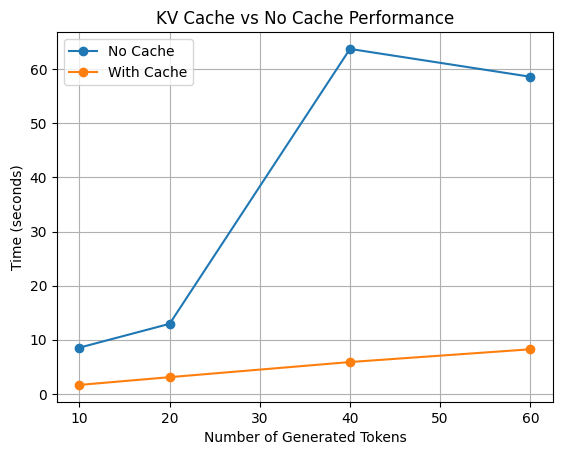

In [7]:
plt.figure()
plt.plot(token_list, no_cache_times, marker='o', label="No Cache")
plt.plot(token_list, cache_times, marker='o', label="With Cache")

plt.xlabel("Number of Generated Tokens")
plt.ylabel("Time (seconds)")
plt.title("KV Cache vs No Cache Performance")
plt.legend()
plt.grid()

plt.show()

## 9.Show Speedup



---



In [8]:
for i, tokens in enumerate(token_list):
    speedup = no_cache_times[i] / cache_times[i]
    print(f"Tokens: {tokens} | Speedup: {speedup:.2f}x")

Tokens: 10 | Speedup: 5.15x
Tokens: 20 | Speedup: 4.19x
Tokens: 40 | Speedup: 10.83x
Tokens: 60 | Speedup: 7.11x


## 10.Show Generated Text



---



In [9]:
out_no_cache = generate_no_cache(prompt, max_new_tokens=40)
out_cache = generate_with_cache(prompt, max_new_tokens=40)

text_no_cache = tokenizer.decode(out_no_cache[0], skip_special_tokens=True)
text_cache = tokenizer.decode(out_cache[0], skip_special_tokens=True)

print("🔴 No Cache Output:\n")
print(text_no_cache[:])

print("\n" + "="*80 + "\n")

print("🟢 With Cache Output:\n")
print(text_cache[:])

print("\nOutputs identical:", text_no_cache == text_cache)

🔴 No Cache Output:

KV caching improves text generation efficiency because it reduces the number of bytes needed to store the text.

The text is stored in a separate buffer, which is then used to generate the HTML.

The HTML is then rendered to


🟢 With Cache Output:

KV caching improves text generation efficiency because it reduces the number of bytes needed to store the text.

The text is stored in a separate buffer, which is then used to generate the HTML.

The HTML is then rendered to

Outputs identical: True


## 11.Observations



---



- No-cache latency increases rapidly with sequence length
- KV cache significantly reduces generation time
- Speedup becomes more pronounced for longer sequences